In [ ]:
# import pandas as pd
# df = pd.read_csv('papermodeldata(in).csv')
# len(df.columns) -5 

# df['ttd'].isnull().any()
# df['fold'].isnull().any()
# df['time'].isnull().any()
# df['y'].isnull().any()

# df['VitalID'].groupby(df['VitalID']).count()
# df_dead = df[df['y'] == 1]
# df_alive = df[df['y'] == 0]

# df_alive['VitalID'].groupby(df_alive['VitalID']).count()

In [ ]:
# have the original dataframe 
# analyze null values for each using the dataframe
# analyze hit rates for that using the dataframe 
# compile a list of valid_indices
# get the final valid dataframe

In [34]:
import scipy.io
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import pickle as pl
from collections import OrderedDict
import traceback
import random
import threading
import math

### Exploring the structure one mat file

In [ ]:
# The sample data doesnt have any useful things to use
# pname and pdata are metadata of the patient id 
# v data and v name are the vitals and the values
mat_file = scipy.io.loadmat('./download/Vitals/NICU_1005_vitals.mat')

In [10]:
mat_file.keys()

dict_keys(['__header__', '__version__', '__globals__', 'pdata', 'pname', 'vdata', 'vname', 'vt'])

In [11]:
columns= [str(i[0]) for i in list(mat_file['pname'].reshape(-1))]
print(columns)

['PatientID', 'BirthTime', 'BirthWeight', 'GestAge', 'GestAgeDays', 'Male', 'APGAR1', 'APGAR5', 'APGAR10', 'Age at Death']


In [12]:
mat_file['pname']

array([[array(['PatientID'], dtype='<U9')],
       [array(['BirthTime'], dtype='<U9')],
       [array(['BirthWeight'], dtype='<U11')],
       [array(['GestAge'], dtype='<U7')],
       [array(['GestAgeDays'], dtype='<U11')],
       [array(['Male'], dtype='<U4')],
       [array(['APGAR1'], dtype='<U6')],
       [array(['APGAR5'], dtype='<U6')],
       [array(['APGAR10'], dtype='<U7')],
       [array(['Age at Death'], dtype='<U12')]], dtype=object)

In [13]:
mat_file['pdata']

array([[1005.,  180.,  351.,   24.,    6.,    0.,    6.,    4.,    7.,
          nan]])

In [15]:
mat_file['vname']

array([[array(['HR'], dtype='<U2')],
       [array(['RESP'], dtype='<U4')],
       [array(['SPO2-%'], dtype='<U6')],
       [array(['SPO2-R'], dtype='<U6')],
       [array(['NBP-S'], dtype='<U5')],
       [array(['NBP-D'], dtype='<U5')],
       [array(['NBP-M'], dtype='<U5')]], dtype=object)

In [14]:
mat_file['vdata']

array([[139.,  37.,  nan, ...,  nan,  nan,  nan],
       [140.,  36.,  nan, ...,  nan,  nan,  nan],
       [140.,  37.,  nan, ...,  nan,  nan,  nan],
       ...,
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], shape=(464509, 7))

### Creating the Patient data from the samples data and the vitals metadata 

In [127]:
mat_files = sorted(glob.glob('./download/Vitals/*.mat'))

In [130]:
baby_ids = [file.split('/')[-1].split('_')[1] for file in mat_files]

In [ ]:
dataframes = [ pd.DataFrame(scipy.io.loadmat(file)['pdata'],columns=columns) for file in mat_files]

In [ ]:
metadata_df = pd.concat(dataframes,ignore_index=True)
metadata_df = metadata_df.rename(columns={'PatientID': 'baby_id'})

In [ ]:
with open('metadata_df.pkl','wb') as f:
    pl.dump(f)

In [ ]:
# Question:
# see the null and non-null distribution of 
# id column and the data columns
# (to validate if hr and spo2 are only important) across all mat files

# Analysis:
# Seeing how many null values are there

In [ ]:
# # to see distribution and null percentage of one mat file
# for i in range(data.shape[1]):
#     plt.subplot(1, 3, 1)
#     plt.hist(data[:,i].flatten(), bins=50, alpha=0.7)
#     plt.title(f'{names[i]}')
#     plt.ylabel('Frequency')
#     plt.tight_layout()
#     plt.show()
    
# print("Null values in data columns:")
# for i in range(data.shape[1]):
#     null_count = np.isnan(data[:, i]).sum()
#     total_count = len(data[:, i])
#     print(f"{names[i]}: {null_count} nulls out of {total_count} ({null_count/total_count*100:.1f}%)")

In [ ]:
# Question: 
# see the null and non-null distribution of time_columns values 

# Analysis:
# some values are negative 
# the seconds don't start from (aka measurement doesnt start from midnigt when the baby is born)
# the frequency of measurements within intervals were erratic 

### Saving the context size, birth time and age_at_death arrays

In [ ]:
context_size_arr = []
for file in mat_files:
    time_values = scipy.io.loadmat(file)['vt'].reshape(-1) 
    context_size_arr.append(time_values[-1]-time_values[0])

In [ ]:
age_at_death_arr = [scipy.io.loadmat(file)['pdata'][0][-1] for file in mat_files ]

In [ ]:
birth_time_arr = [scipy.io.loadmat(file)['pdata'][0][1] for file in mat_files ]

In [ ]:
with open('context_size.pkl','wb') as f:
    pl.dump(context_size_arr,f)

In [ ]:
with open('age_at_death.pkl','wb') as f:
    pl.dump(age_at_death_arr,f)

In [ ]:
with open('birth_time.pkl','wb') as f:
    pl.dump(birth_time_arr,f)

#### see the no of files which perish  and see the no of files which do not perish 

In [ ]:
with open('./age_at_death.pkl','rb') as f:
    arr = pl.load(f)

In [ ]:
print("Total Count: " + str(len(arr)))
nan_count = np.isnan(arr).sum()
print(f"Non-NICU count: {nan_count}")
print(f"NICU count: {len(arr)-nan_count}")

In [ ]:
indicator_vector = []
for i in arr:
    if(np.isnan(i)):
        indicator_vector.append(0)
    else:
        indicator_vector.append(1)
    

In [ ]:
with open('indicator_vector.pkl', 'wb') as f:
    pl.dump(indicator_vector, f)

#### Seeing the context size distriubution of the context size for NICU and non NICU

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/context_size.pkl','rb') as f:
    arr_context_size = pl.load(f)

In [ ]:
arr_context_size_nicu = []
arr_context_size_nonnicu = []

for i in range(len(indicator_vector)) :
    if(indicator_vector[i]==0):
        arr_context_size_nonnicu.append(arr_context_size[i])
    else:
        arr_context_size_nicu.append(arr_context_size[i])

In [ ]:
# seeing the distribution of the values 
plt.hist(arr_context_size_nicu , bins=10, edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Values')
plt.xlim(0, 3.5e+7) 
plt.grid(True)
plt.show()

### Analysing birth time pkl file

In [ ]:
with open('birth_time.pkl','rb') as f:
    birth_time_values = pl.load(f)

In [ ]:
print("Birth values:")
print(f"  Null:     {np.isnan(birth_time_values).sum():>5} ({np.isnan(birth_time_values).mean()*100:>6.2f}%)")
print(f"  Non-null: {(~np.isnan(birth_time_values)).sum():>5} ({(~np.isnan(birth_time_values)).mean():>6.2f}%)\n")

In [ ]:
# within every 5 minute interval after 0 and until ttd, how many datapoints are complete.(100% window coverage)(atleast one valid datapoint in every window)
# within every 5 minutes interval after first observation , and until the last observation, how many datapoints are complete(100% window coverage)(atleast one valid datapoint in every window)

# the ttd is not given and from the readme, it seems the last observation doesnt coincide the ttd..but first we need to find the first ttd
# np.float64(0.9524762381190596) of the datapoitns have there ageatdeath as NaN

In [ ]:
# What wre we lloking for ? one of the two options?is it till startobserv,last observ or 0,ttd
# what is a valid datapoint for us ? do we include resp as well along with the cols we think?

In [ ]:
# x1,y1
# x2,y2
# sum(totalx,totaly)

#### Checking window coverage for HR and SP02 (vectorized and non-vectorized approach)

In [ ]:
# timestamps: [2,3,5],  hr[null, 3, null]  spo2[null,2,3]
# timestamps - take min and max 
# distribute it step size = 2 
# copy voer the valid values for the timestamps 
# do the analaysis for per 5 time windows (misses,hits,noofwindows)

# store the true, false arrays in pickle files
# hits,no of windows  for this particular window size
# one row for each baby for a particular window size
# cols would be window sizes.

# do this for every baby 

In [ ]:
# take the hr values and see which are non null 
# take the sp2 values and see which are non null 
# do the and to find the values which have non-null hr and sp02
# store this and the timestamps array

# for wsize in sizes:
#   for baby in babies:
        # timestamp is sorted array
        # the first window starts from the first timestamp
        # see if the next value is in the current window, if yes, assign the window a hit
        # see if the next value is in the next window, increment the counter to see the next window by the window size
        # else, see how many middle windows we have missed 
        # append the (no of misses, hits, and total no of windows)

In [ ]:
# take the start and end timestamp to figure out the no of windows

# you only need the timestamp info to be stored later to compute for arbitary window sizes
# since you can just take the timestamp with corresponding true in final_arr
# basiclaly in order to sae compute jsut assign those invalid timestamps to be null

# after getting those valid timestamps, you then iterate through the timestamps and then group timestamps in one window to one timestamp
# start with a timestamp, icnrement the counter
# if timestamp!=null
# see if the next is within the 300 s and skip it 
# once you find one which is not, windowsize - (timestamp - 300*(timestamp-orig)/300)), increment the counter 
# see if the next one is within that range and skip it 

# we have the no of hits, then we have the no of windows, no of misses = no of windows - no of hits

In [ ]:
# we are starting the measurement from a valid timestamp since we need to know where to start the window strides. We cant jsut start from the first global timstamp
# we are assuming the timestamps are non-null and sorted

In [ ]:
# We run both of the window coverages cause we need to verify that each one works and we get the correct hit rate 
# The final df released by these window coverage methods doesn't include files which dont even have HR and SPO2 columns

In [ ]:
# code to check for whether the vname can be hardcoded or not
mat_files = sorted(glob.glob('./download/Vitals/*.mat'))
false_num = 0
for i, file_path in enumerate(mat_files):
        mat_data = scipy.io.loadmat(file_path)
        
        try:
             bool1 = mat_data['vname'][0][0][0] == 'HR'
             bool2 = mat_data['vname'][2][0][0] == 'SPO2-%'
        
        except:
             print(file_path)
             print(mat_data['vname'])
                
        final_bool = bool1 and bool2
        if not(final_bool):
                false_num+=1
                

In [ ]:
# ./download/Vitals/NICU_1169_vitals.mat
# ./download/Vitals/NICU_1527_vitals.mat
# ./download/Vitals/NICU_3866_vitals.mat
# ./download/Vitals/NICU_4933_vitals.mat
# ./download/Vitals/NICU_5294_vitals.mat
# ./download/Vitals/NICU_6283_vitals.mat
# ./download/Vitals/NICU_6647_vitals.mat
# ./download/Vitals/NICU_6745_vitals.mat
# ./download/Vitals/NICU_7799_vitals.mat
# ./download/Vitals/NICU_8761_vitals.mat
# dont have either of the columns

In [ ]:
# # Find HR and SPO2 columns
# hr_cols = mat_data['vdata'][:,0]
# spo2_cols = mat_data['vdata'][:,2]
# valid_timestamps = mat_data['vt']

# # Step 1: Filter for non-null HR and SPO2 values
# final_arr = ~np.isnan(hr_cols) & ~np.isnan(spo2_cols)

In [ ]:
def analyze_coverage_non_optimal(all_timestamps, results, wsize, final_arr):
    """
    Analyze window coverage for a specific window size
    """
    # Filter for valid timestamps only (where final_arr is True)
    valid_timestamps = all_timestamps[final_arr]
    
    # record_timestamps = []


    # Define the overall time range (from first to last timestamp in ALL data)
    first_overall = all_timestamps[0].item()
    last_overall = all_timestamps[-1].item()
    
    # Calculate total number of windows
    total_duration = last_overall - first_overall
    total_windows = int(np.floor(total_duration / wsize))  + 1
    
    if len(valid_timestamps) == 0:
        results[wsize] = {
            'hits': 0,
            'misses': total_windows, 
            'total_windows': total_windows,
            'coverage_rate': 0
        }
        return
    
    hits = 0
    
    # Iterate through each possible window
    for window_idx in range(total_windows):
        # Define current window boundaries
        window_start = first_overall + (window_idx * wsize)
        window_end = window_start + wsize
        
        # Check if any valid timestamps fall within this window
        timestamps_in_window = valid_timestamps[
            (valid_timestamps >= window_start) & 
            (valid_timestamps < window_end)
        ]
        
        # timestamps_in_window = list(timestamps_in_window.reshape(-1))
        
        # If there's at least one valid timestamp in this window, it's a hit
        if len(timestamps_in_window) > 0:
            # record_timestamps.append(timestamps_in_window[0])
            hits += 1
    
    # Calculate misses
    misses = total_windows - hits
    
    results[wsize] = {
        'hits': hits,
        'misses': misses, 
        'total_windows': total_windows,
        'coverage_rate': hits / total_windows if total_windows > 0 else 0
    }
    
    # return list(record_timestamps)

In [ ]:
def analyze_coverage_vectorized(all_timestamps, results, wsize, final_arr):
    """
    Vectorized version - faster for large datasets
    """
    valid_timestamps = all_timestamps[final_arr]
    total_duration = all_timestamps[-1] - all_timestamps[0]
    total_windows = int(np.floor(total_duration / wsize))  + 1
    
    # record_timestamps = []
        
        
    if len(valid_timestamps) == 0:
        results[wsize] = {
            'hits': 0, 
            'misses': total_windows, 
            'total_windows': total_windows,
            'coverage_rate': 0
        }
        return
    
    first_overall = all_timestamps[0].item()
    last_overall = all_timestamps[-1].item()
    
    # Vectorized approach: assign each timestamp to a window
    window_indices = np.floor((valid_timestamps - first_overall) / wsize).astype(int)
    
    # Count unique windows that have at least one timestamp
    unique_windows = np.unique(window_indices)
    hits = len(unique_windows)    
    
    misses = total_windows - hits
    
    results[wsize] = {
        'hits': hits,
        'misses': misses,
        'total_windows': total_windows,
        'coverage_rate': hits / total_windows if total_windows > 0 else 0
    }

    # return list(record_timestamps)

In [ ]:
def analyze_baby_window_coverage(mat_file_path, window_sizes,optimized):
    """
    Analyze window coverage for a single baby across different window sizes
    """
    # Load mat file
    mat_data = scipy.io.loadmat(mat_file_path)
    vname = mat_data['vname']
    
    if 'HR' in vname and 'SPO2-%' in vname:
        if (vname[0][0][0] == 'HR') and (vname[2][0][0] == 'SPO2-%'): 
            hr_cols = mat_data['vdata'][:,0]
            spo2_cols = mat_data['vdata'][:,2]
        else:
            hr_cols = mat_data['vdata'][:,vname.index('HR')]
            spo2_cols = mat_data['vdata'][:,vname.index('SPO2-%')]
    else:
        raise Exception(f"{mat_file_path}: File does not have HR or SPO2")
    
    valid_timestamps = mat_data['vt']
    
    # Step 1: Filter for non-null HR and SPO2 values
    final_arr = ~np.isnan(hr_cols) & ~np.isnan(spo2_cols)
    
    # Step 2: Analyze for each window size
    results = {}
    for wsize in window_sizes:
        # print(f"Analyzing for {mat_file_path}")
        # print(f" - analyzing for window size: {wsize}")
        
        if(optimized):
            analyze_coverage_vectorized(valid_timestamps, results, wsize, final_arr)
            # return analyze_coverage_vectorized(valid_timestamps, results, wsize, final_arr)
            
        else:
            analyze_coverage_non_optimal(valid_timestamps, results, wsize, final_arr)
            # analyze_coverage(valid_timestamps,results,wsize,final_arr)
            # return analyze_coverage_non_optimal(valid_timestamps, results, wsize, final_arr)
    
    return results

In [ ]:
def save_results_to_pickle(summary_df, baby_results, window_sizes,filename):
    """Save results to pickle file"""
    results_dict = {
        'summary_df': summary_df,
        'baby_results': baby_results,
        'window_sizes': window_sizes
    }
    
    with open(filename, 'wb') as f:
        pl.dump(results_dict, f)
    
    print(f"Results saved to {filename}")

In [ ]:
def analyze_all_babies_windows(window_sizes,mat_files,optimized,filename):
    """
    Analyze window coverage for all babies across different window sizes
    """
    
    # Store results for each baby and window size
    all_results = []
    baby_results = {}
    
    print(f"Analyzing {len(mat_files)} babies with window sizes: {window_sizes}")
    
    for i, file_path in enumerate(mat_files):
        print(f"\nProcessing baby {i+1}/{len(mat_files)}: {file_path}")
        
        try:
            # Analyze this baby
            baby_result = analyze_baby_window_coverage(file_path, window_sizes,optimized)
            
        except:
            traceback.print_exc()
            continue
            
        baby_id = file_path.split('/')[-1]  # Extract filename as baby ID
        baby_results[baby_id] = baby_result
        
        # Create a row for summary DataFrame
        row = OrderedDict()
        row['baby_id'] = baby_id
        for wsize in window_sizes:
            row[f'coverage_{wsize}s'] = baby_result[wsize]['coverage_rate']
            row[f'hits_{wsize}s'] = baby_result[wsize]['hits']
            row[f'total_windows_{wsize}s'] = baby_result[wsize]['total_windows']
        
        all_results.append(row)
        
        if(i%60==0):
            save_results_to_pickle(pd.DataFrame(all_results), baby_results,window_sizes, filename=filename)
                    
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(all_results)
    
    return summary_df, baby_results

In [ ]:
# Define window sizes (in seconds)
window_sizes = [60,120,180,300,600]  # 1min, 2min, 3min, 5min, 10min,

In [ ]:
def run_non_optimal_analysis():
    """Thread function for non-optimal analysis"""
    filename = 'results_non_optimal_1.pkl'
    print("Starting non-optimal analysis...")
    summary_df, baby_results = analyze_all_babies_windows(window_sizes, mat_files, False, filename)
    save_results_to_pickle(summary_df, baby_results, window_sizes, filename=filename)
    print("Non-optimal analysis completed!")

def run_vectorized_analysis():
    """Thread function for vectorized analysis"""
    filename = 'results_vectorized_1.pkl'
    print("Starting vectorized analysis...")
    summary_df, baby_results = analyze_all_babies_windows(window_sizes, mat_files, True, filename)
    save_results_to_pickle(summary_df, baby_results, window_sizes, filename=filename)
    print("Vectorized analysis completed!")

# Create threads
thread_non_optimal = threading.Thread(target=run_non_optimal_analysis)
thread_vectorized = threading.Thread(target=run_vectorized_analysis)

# Start both threads
print("Starting both analyses concurrently...")
thread_non_optimal.start()
thread_vectorized.start()

# Wait for both to complete
thread_non_optimal.join()
thread_vectorized.join()

print("Both analyses completed!")

## validating vectorized vs non_optimal approach

In [106]:
with open('../EDA/old/results_non_optimal_fixed.pkl','rb') as f:
    df_non_optimal = pl.load(f)['summary_df']

In [107]:
with open('../EDA/old/results_vectorized_fixed.pkl','rb') as f:
    df_vectorized = pl.load(f)['summary_df']

In [108]:
columns_to_compare = set(df_non_optimal.columns) & set(df_vectorized.columns) - set("baby_id")

In [109]:
different_ids = set()
baby_ids_list = list(df_non_optimal['baby_id'])
for column in columns_to_compare:
    for id in baby_ids_list:
        if(df_vectorized[df_vectorized['baby_id']==id][column].values[0] != df_non_optimal[df_non_optimal['baby_id']==id][column].values[0]):
            different_ids.add(id)

In [ ]:
df_non_optimal[df_non_optimal['baby_id'].isin(list(different_ids))]

In [ ]:
df_vectorized[df_vectorized['baby_id'].isin(list(different_ids))]

In [ ]:
# learnings 
# always validate your code , with different approaches 
# follow your gut feeling and alway establish that the assumptions are true...for eg sorted, column positions 
# never do inplace (although helps during memeory bottlenecks)

### Visualizing the hit rate of the summary df

In [116]:
with open('../EDA/old/results_vectorized_fixed.pkl','rb') as f:
    dic = pl.load(f)

In [117]:
raw_summary_dic = dic['summary_df']

In [118]:
coverage_cols = [col for col in raw_summary_dic.columns if 'coverage' in col]
for col in coverage_cols:
    print(f"\n{col}:")
    print(f"  Mean: {raw_summary_dic [col].mean():.4f}")
    print(f"  Median: {raw_summary_dic [col].median():.4f}")
    print(f"  25th percentile: {raw_summary_dic [col].quantile(0.25):.4f}")
    print(f"  75th percentile: {raw_summary_dic [col].quantile(0.75):.4f}")
    print(f"  Min: {raw_summary_dic [col].min():.4f}")
    print(f"  Max: {raw_summary_dic [col].max():.4f}")


coverage_60s:
  Mean: 0.8560
  Median: 0.9453
  25th percentile: 0.8085
  75th percentile: 0.9812
  Min: 0.0000
  Max: 1.0000

coverage_180s:
  Mean: 0.8619
  Median: 0.9517
  25th percentile: 0.8148
  75th percentile: 0.9876
  Min: 0.0000
  Max: 1.1667

coverage_300s:
  Mean: 0.8639
  Median: 0.9542
  25th percentile: 0.8167
  75th percentile: 0.9896
  Min: 0.0000
  Max: 1.0196

coverage_600s:
  Mean: 0.8665
  Median: 0.9566
  25th percentile: 0.8203
  75th percentile: 0.9922
  Min: 0.0000
  Max: 1.0011


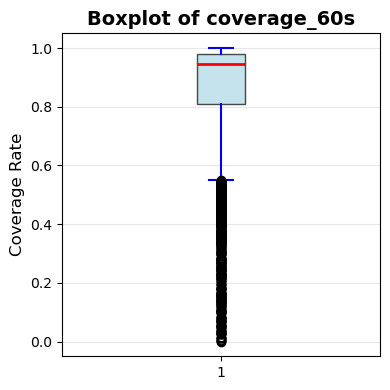

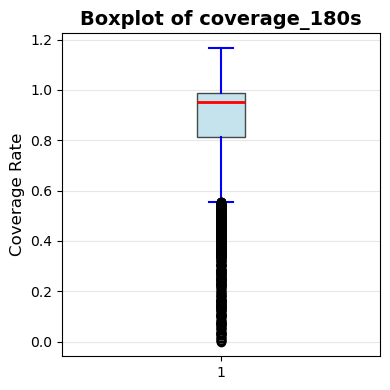

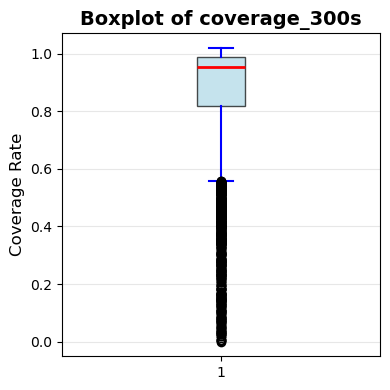

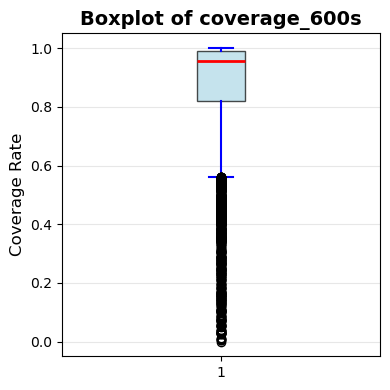

In [119]:
for col in coverage_cols:
    plt.figure(figsize=(4, 4))
    plt.boxplot(raw_summary_dic[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue', linewidth=1.5),
                capprops=dict(color='blue', linewidth=1.5))
    plt.ylabel('Coverage Rate', fontsize=12)
    plt.title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [120]:
valid_summary_dic = raw_summary_dic[raw_summary_dic['coverage_60s'] >= 0.70]

In [121]:
coverage_cols = [col for col in valid_summary_dic.columns if 'coverage' in col]
for col in coverage_cols:
    print(f"\n{col}:")
    print(f"  Mean: {valid_summary_dic[col].mean():.4f}")
    print(f"  Median: {valid_summary_dic[col].median():.4f}")
    print(f"  25th percentile: {valid_summary_dic[col].quantile(0.25):.4f}")
    print(f"  75th percentile: {valid_summary_dic[col].quantile(0.75):.4f}")
    print(f"  Min: {valid_summary_dic[col].min():.4f}")
    print(f"  Max: {valid_summary_dic[col].max():.4f}")


coverage_60s:
  Mean: 0.9276
  Median: 0.9601
  25th percentile: 0.8912
  75th percentile: 0.9840
  Min: 0.7000
  Max: 1.0000

coverage_180s:
  Mean: 0.9337
  Median: 0.9669
  25th percentile: 0.8977
  75th percentile: 0.9903
  Min: 0.7032
  Max: 1.1667

coverage_300s:
  Mean: 0.9357
  Median: 0.9692
  25th percentile: 0.9003
  75th percentile: 0.9923
  Min: 0.7040
  Max: 1.0196

coverage_600s:
  Mean: 0.9382
  Median: 0.9724
  25th percentile: 0.9026
  75th percentile: 0.9946
  Min: 0.7047
  Max: 1.0011


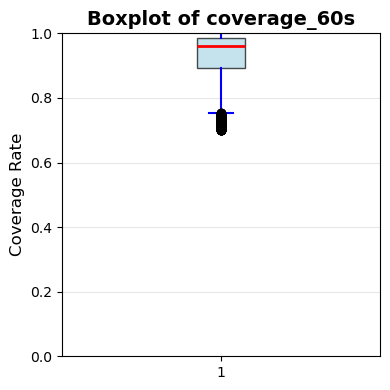

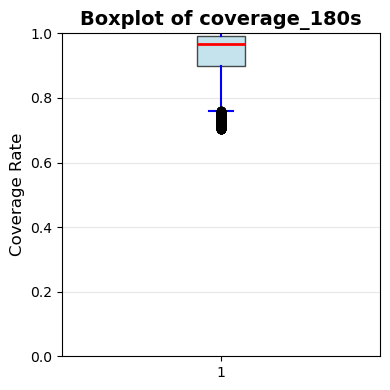

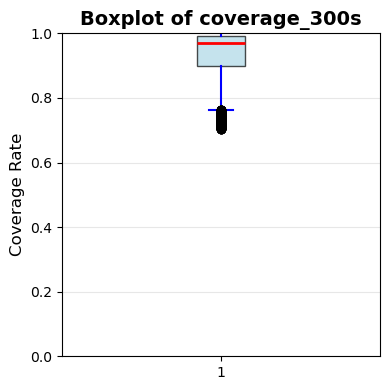

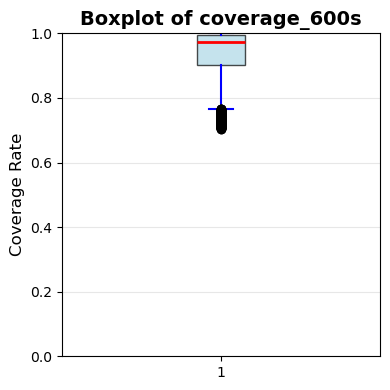

In [122]:
for col in coverage_cols:
    plt.figure(figsize=(4, 4))
    plt.boxplot(valid_summary_dic[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue', linewidth=1.5),
                capprops=dict(color='blue', linewidth=1.5))
    plt.ylabel('Coverage Rate', fontsize=12)
    plt.title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    plt.ylim(0, 1)  
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
baby_id_to_indicator = {}
baby_id_to_context_size = {}

for file_path in mat_files:
    baby_id = file_path.split('/')[-1]
    
    # Load mat file
    mat_data = scipy.io.loadmat(file_path)
    
    # Get age at death
    age_at_death = mat_data['pdata'][0][-1]
    baby_id_to_indicator[baby_id] = 0 if np.isnan(age_at_death) else 1
    
    # Compute context size (time range)
    timestamps = mat_data['vt'].flatten()
    context_size = timestamps[-1] - timestamps[0]
    baby_id_to_context_size[baby_id] = context_size.item()

# Map to dataframe
valid_summary_dic['indicator_vector'] = valid_summary_dic['baby_id'].map(baby_id_to_indicator)
valid_summary_dic['context_size'] = valid_summary_dic['baby_id'].map(baby_id_to_context_size)

In [ ]:
valid_summary_dic[valid_summary_dic['indicator_vector']==0]

### Model approach

In [13]:
import torch
import numpy as np
import pandas as pd
from chronos import Chronos2Pipeline
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

/Users/adityagoyal/miniconda3/envs/baseline_env/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/Users/adityagoyal/miniconda3/envs/baseline_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [124]:
with open('valid_summary_dic.pkl','rb') as f:
    valid_summary_dic = pl.load(f)
mat_file_names = valid_summary_dic['baby_id']

In [78]:
indicator_vector = list(valid_summary_dic['indicator_vector'])

In [57]:
def create_windowed_features_vectorized(mat_file_path, window_size, context_size):
    """
    Vectorized version - faster for large datasets
    """
    # Load mat file
    mat_data = scipy.io.loadmat(mat_file_path)
    vname = mat_data['vname']
    
    # Get HR and SPO2 columns
    if 'HR' in vname and 'SPO2-%' in vname:
        if (vname[0][0][0] == 'HR') and (vname[2][0][0] == 'SPO2-%'): 
            hr_cols = mat_data['vdata'][:,0]
            spo2_cols = mat_data['vdata'][:,2]
        else:
            hr_cols = mat_data['vdata'][:,vname.index('HR')]
            spo2_cols = mat_data['vdata'][:,vname.index('SPO2-%')]
    else:
        raise Exception(f"{mat_file_path}: File does not have HR or SPO2")
    
    timestamps = mat_data['vt'].flatten()
    first_timestamp = timestamps[0].item()
    
    # Calculate which window each timestamp belongs to
    window_indices = np.floor((timestamps - first_timestamp) / window_size).astype(int)
    
    # Filter to only include timestamps within context window
    context_mask = (timestamps - first_timestamp) < context_size
    window_indices = window_indices[context_mask]
    hr_cols_filtered = hr_cols[context_mask]
    spo2_cols_filtered = spo2_cols[context_mask]
    
    # Calculate number of windows
    num_windows = int(np.ceil(context_size / window_size))
    
    # Initialize arrays
    hr_windows = np.full(num_windows, np.nan)
    spo2_windows = np.full(num_windows, np.nan)
    
    # Compute average for each window
    for window_idx in range(num_windows):
        mask = window_indices == window_idx
        
        if np.any(mask):
            hr_values = hr_cols_filtered[mask]
            spo2_values = spo2_cols_filtered[mask]
            
            hr_windows[window_idx] = np.nanmean(hr_values)
            spo2_windows[window_idx] = np.nanmean(spo2_values)
    
    window_starts = first_timestamp + np.arange(num_windows) * window_size
    
    return {
        'hr_windows': hr_windows,
        'spo2_windows': spo2_windows,
        'window_starts': window_starts,
        'num_windows': num_windows,
        'window_size': window_size,
        'context_size': context_size,
        'first_timestamp': first_timestamp
    }

In [58]:
def create_embeddings(hr_data,spo2_data,pipeline):

    # Convert to tensor and add n_variates dimension
    # Shape: (1, seq_len) -> (1, 1, seq_len)
    hr_tensor = torch.tensor(hr_data, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    spo2_tensor = torch.tensor(spo2_data, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    
    # Stack into batch: (2, 1, seq_len) - 2 series, 1 variate each
    context = torch.cat([hr_tensor, spo2_tensor], dim=0)

    # Get embeddings using the pipeline's internal method
    with torch.no_grad():
        embeddings,_ = pipeline.embed(context)

    print(f"Input shape: {context.shape}")
    # print(f"Embeddings shape: {embeddings}")
    
    return embeddings
    

In [59]:


# Custom Dataset
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = [torch.FloatTensor(emb) for emb in embeddings]
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Simple Classifier
class SimpleClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=128, num_classes=2):
        super(SimpleClassifier, self).__init__()
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for embeddings, labels in dataloader:
        embeddings = embeddings.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Validation function
def validate_epoch(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for embeddings, labels in dataloader:
            embeddings = embeddings.to(device)
            labels = labels.to(device)
            
            outputs = model(embeddings)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    
    return accuracy, precision, recall, f1, auc

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        """
        Focal Loss for binary/multi-class classification
        
        Args:
            alpha: weighting factor in [0,1] to balance positive/negative examples
            gamma: focusing parameter for modulating loss (gamma >= 0)
            reduction: 'none' | 'mean' | 'sum'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [15]:
def k_fold_cross_validation(embeddings_list, labels, k=10, epochs=20, batch_size=32, 
                            learning_rate=0.01, device='cpu',use_focal_loss=True):
    """
    K-fold cross-validation - returns only average and std metrics
    
    Args:
        embeddings_list: list of embeddings
        labels: array of 0s and 1s
        k: number of folds
        epochs: training epochs per fold
        batch_size: batch size
        learning_rate: learning rate
        device: 'cpu' or 'cuda'
    
    Returns:
        avg_metrics: dict with average metrics
        std_metrics: dict with standard deviation of metrics
    """
    
    embeddings_array = np.array(embeddings_list)
    labels = np.array(labels)
    embedding_dim = embeddings_array[0].flatten().shape[0]
    
    print(f"K-Fold Cross Validation (k={k})")
    print(f"Samples: {len(labels)} | Embedding dim: {embedding_dim}")
    print(f"Class distribution: {np.bincount(labels)}\n")
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    fold_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(embeddings_array, labels)):
        print(f"Fold {fold + 1}/{k}...", end=" ")
        
        X_train, X_val = embeddings_array[train_idx], embeddings_array[val_idx]
        y_train, y_val = labels[train_idx], labels[val_idx]
        
        train_dataset = EmbeddingDataset(X_train, y_train)
        val_dataset = EmbeddingDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        model = SimpleClassifier(embedding_dim).to(device)
        # Choose loss function
        if use_focal_loss:
            criterion = FocalLoss(alpha=0.25, gamma=2.0)  # Adjust alpha/gamma as needed
        else:
            criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
        # Train for all epochs
        for epoch in range(epochs):
            train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate on validation set after all training is done
        val_acc, val_prec, val_rec, val_f1, val_auc = validate_epoch(model, val_loader, device)
        
        # Store metrics for this fold
        fold_metrics.append({
            'accuracy': val_acc,
            'precision': val_prec,
            'recall': val_rec,
            'f1': val_f1,
            'auc': val_auc
        })
        
        print(f"Val F1: {val_f1:.4f}, Val Acc: {val_acc:.4f}")
    
    # Calculate average and std across all folds
    avg_metrics = {metric: np.mean([fold[metric] for fold in fold_metrics]) 
                   for metric in fold_metrics[0].keys()}
    std_metrics = {metric: np.std([fold[metric] for fold in fold_metrics]) 
                   for metric in fold_metrics[0].keys()}
    
    print(f"\n{'='*60}")
    print("K-Fold Cross-Validation Results")
    print(f"{'='*60}")
    for metric in avg_metrics:
        print(f"{metric.capitalize():12s}: {avg_metrics[metric]:.4f} ± {std_metrics[metric]:.4f}")
    
    return avg_metrics, std_metrics,fold_metrics

In [16]:
# pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", 
#                                             device_map="cpu", 
#                                             dtype=torch.float32,)

In [ ]:
base_dir = "/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/"
window_size = 100
context_size = 50000

embeddings_list = []

for file_name in mat_file_names:
    results = create_windowed_features_vectorized(f"{base_dir}/{file_name}", window_size, context_size)
    embeddings = create_embeddings(results['hr_windows'],results['spo2_windows'],pipeline)
    
    hr_embedding = embeddings[0][0][-1]
    spo2_embedding = embeddings[1][0][-1]
    combined_embedding = torch.cat([hr_embedding, spo2_embedding], dim=0)
    embeddings_list.append(combined_embedding.cpu().numpy())

In [10]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/embeddings.pkl','rb') as f:
    embeddings_list = pl.load(f)

In [11]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/indicator_vector.pkl','rb') as f:
    indicator_vector = pl.load(f)

In [ ]:
avg_metrics,std_metrics,fold_metrics = k_fold_cross_validation(embeddings_list, indicator_vector, k=5, epochs=50, batch_size=32, 
                            learning_rate=0.01, device='cpu')

In [ ]:
# (batch_size, context_length, d_model)

In [107]:
with open('fold_metrics_1','wb') as f:
    pl.dump(fold_metrics,f)

In [29]:
with open('valid_summary_dic.pkl','rb') as f:
    summary_df = pl.load(f)

In [59]:
mat_file = scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/NICU_6626_vitals.mat")

In [60]:
baby_ids = summary_df['baby_id']

In [ ]:
gest_age_files = [scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/{fid}")['pdata'][0][3]  for fid in baby_ids]
gest_age_days_files = [scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/{fid}")['pdata'][0][4]  for fid in baby_ids]

In [62]:
birth_weight_files = [scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/{fid}")['pdata'][0][2]  for fid in baby_ids]

In [65]:
with open('birth_weight_files.pkl','wb') as f:
    pl.dump(birth_weight_files,f)

In [55]:
with open('valid_gest_age_files.pkl','wb') as f:
    pl.dump(gest_age_files,f)

In [56]:
with open('valid_gest_age_days_files.pkl','wb') as f:
    pl.dump(gest_age_days_files,f)

In [108]:
birth_weight_files_arr = [  (age == None or np.isnan(age))  for age in birth_weight_files ]
gest_age_files_arr = [ (age == None or np.isnan(age))  for age in gest_age_files ]
gest_age_days_files_arr = [ (age == None or np.isnan(age))  for age in gest_age_days_files ]

In [109]:
print(  float(sum(gest_age_files_arr)) / len(gest_age_files_arr)   )
print(  float(sum(gest_age_days_files_arr)) / len(gest_age_days_files_arr)      )
print(   float(sum(birth_weight_files_arr))  /  len(birth_weight_files_arr)     )

0.0005967774020290431
0.24030236721702805
0.002188183807439825


In [110]:
indicator_vector = list(summary_df['indicator_vector'])

## seeing if there is any signifcant statistical differecne between the perished NICU children and those who didnt perosh

In [122]:
sume_1 = 0.0
valid_label_1 = 0
arr_1 = []
for i in range(len(birth_weight_files)):
    if(indicator_vector[i]==1) and (birth_weight_files_arr[i] == 0):
        sume_1 += birth_weight_files[i]
        valid_label_1+=1
        arr_1.append(birth_weight_files[i])

In [123]:
sume_0 = 0.0
valid_label_0 = 0
arr_0 = []
for i in range(len(birth_weight_files)):
    if(indicator_vector[i]==0) and (birth_weight_files_arr[i] == 0):
        sume_0 += birth_weight_files[i]
        valid_label_0 += 1
        arr_0.append(birth_weight_files[i])

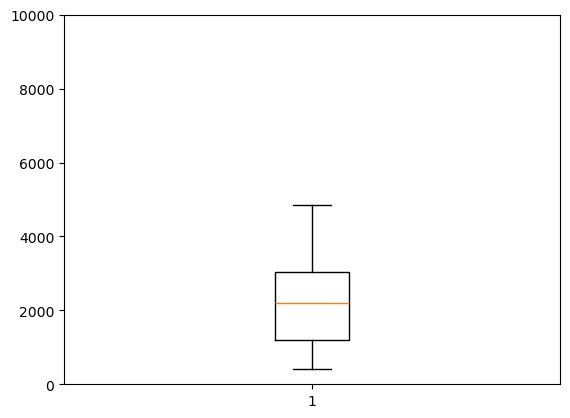

In [129]:
plt.boxplot(arr_1)
plt.ylim(0, 10000)
plt.show()

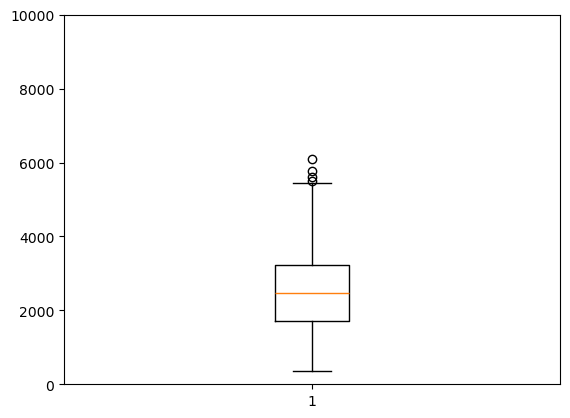

In [130]:
plt.boxplot(arr_0)
plt.ylim(0, 10000)
plt.show()